In [2]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [3]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans


import xgboost as xgb

In [4]:
df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
df_original

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [5]:
print(f"total number of rows and columns in the dataset: {len(df_original.columns)} columns, {len(df_original)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [6]:
## Grouping years into decodes
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Makedatetime = Cleaning_date_to_year(df_original)

Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


In [7]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Makedatetime)

In [8]:
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Index_more : {len(Index_more)} attribuue : {Index_more}")
    print(f"Index_less : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("Missing values more than 0.4% : Delete")



more than 0.4% : 4
less than 0.4% : 45
Index_more : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Index_less : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City_Town_3', 

In [9]:
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'Year' , 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Makedatetime, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')

print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

total number of rows and columns in the dataset: 36 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_8744\3032694163.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_8744\3032694163.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


##

### Biological Feature Engineering

In [10]:
df_Feature_engineer = df_Clean_already.copy()
real_number = 1

In [11]:
df_Feature_engineer[['Depth_m']].describe()

,Depth_m
count,6112.000000
mean,6.471188
std,3.467763
min,0.100000
25%,4.000000
50%,6.000000
75%,10.000000
max,23.000000


In [12]:
# โอกาสเกิด ปะการังฟอกขาวต่ำ เพราะโดนเเสงน้อย
df_Feature_engineer[
    (df_Feature_engineer['Depth_m'] > 10) & 
    (df_Feature_engineer['Depth_m'] <= 23)
].describe()

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
count,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,...,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000,679.000000
mean,7.847827,32.452610,12.683358,3.402603,294.922135,302.003382,300.981051,296.882530,304.986167,1.322992,...,2.601427,-1.384839,2.401382,1.811728,8.316863,1.021814,1.124534,1.312066,9.851350,0.523851
std,11.956098,99.613289,2.009191,9.625054,14.717678,1.724314,1.209361,1.548303,1.086743,0.382989,...,0.687113,0.638350,2.587843,0.741941,3.885673,1.322792,2.150357,0.761294,4.089445,0.622479
min,-27.520556,-179.335750,10.100000,0.000000,262.150000,295.540000,296.290000,285.260000,301.640000,0.830000,...,1.630000,-5.070000,0.000000,0.680000,3.000000,0.000000,0.000000,0.490000,2.590000,0.130000
25%,4.200083,-69.145111,11.500000,0.000000,299.390000,300.876250,300.230000,296.440000,304.293750,1.140000,...,2.270000,-1.500000,0.000000,1.317000,6.000000,0.000000,0.000000,0.930000,7.275000,0.270000
50%,10.017222,72.944694,12.000000,0.000000,301.440000,302.170000,301.100000,297.250000,305.040000,1.220000,...,2.460000,-1.380000,2.000000,1.550000,7.000000,1.000000,0.000000,1.110000,9.180000,0.380000
75%,16.809833,118.241292,13.000000,2.500000,302.400000,303.310000,301.860000,297.770000,305.600000,1.400000,...,2.825000,-0.870000,4.000000,2.280000,10.000000,2.000000,1.350000,1.550000,11.520000,0.680000
max,28.557472,179.945333,23.000000,100.000000,304.110000,305.260000,303.520000,299.830000,311.010000,4.210000,...,8.553333,-0.130000,21.000000,5.490000,38.000000,20.000000,20.620000,12.260000,46.340000,11.620000


In [13]:
# โอกาสเกิด ปะการังฟอกขาวสูง เพราะโดนเเสงเต็มๆ
df_Feature_engineer[
    (df_Feature_engineer['Depth_m'] > 3) & 
    (df_Feature_engineer['Depth_m'] <= 10)
].describe()

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
count,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,...,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000,4092.000000
mean,6.395994,72.652603,6.810435,2.784361,293.643438,301.682768,300.541405,295.954913,305.153165,1.624873,...,2.795596,-1.797722,2.302500,1.909876,8.736079,1.188605,1.151233,1.493614,10.996765,0.608117
std,15.114181,82.585310,2.202804,9.930362,15.305921,2.143169,1.766711,2.701283,1.476025,0.694600,...,0.911028,1.033599,2.999956,0.724927,4.212985,1.918135,3.077394,1.202768,5.398598,1.077886
min,-28.162528,-179.859361,3.100000,0.000000,262.150000,292.820000,294.300000,284.540000,301.430000,0.800000,...,1.370000,-7.460000,0.000000,0.680000,3.000000,0.000000,0.000000,0.480000,3.410000,0.110000
25%,1.535514,34.865250,5.000000,0.000000,297.635000,300.568304,299.650000,294.345000,304.440000,1.180000,...,2.300000,-2.416667,0.000000,1.390000,6.000000,1.000000,0.000000,1.010000,7.650000,0.330000
50%,6.894750,104.496514,6.000000,0.000000,300.940000,302.237500,301.120000,297.010000,305.270000,1.340000,...,2.600000,-1.440000,1.250000,1.760000,8.000000,1.000000,0.000000,1.290000,9.690000,0.440000
75%,18.262667,123.128049,9.000000,1.000000,302.250000,303.148125,301.840000,297.830000,305.887500,2.040000,...,3.026250,-1.177500,3.000000,2.260000,10.000000,1.000000,1.160000,1.712500,12.850000,0.630000
max,34.098056,179.944167,10.000000,100.000000,304.390000,306.800000,303.340000,299.880000,313.140000,5.820000,...,10.220000,0.000000,25.000000,6.910000,38.000000,20.000000,37.680000,13.930000,49.240000,12.660000


In [14]:
def classify_depth(depth):
    if depth <= 3: return 'risk'
    elif depth <= 10: return 'risk_medium'
    elif depth <= 25: return 'reel'
    else: return 'Deep_Refugia'

df_Feature_engineer['Depth_Class'] = df_Feature_engineer['Depth_m'].apply(classify_depth)

In [15]:
"""
One-hot Encoder Depth_Class
"""

# 1. ล้าง Index ของ DataFrame หลักก่อน
df_Feature_engineer = df_Feature_engineer.reset_index(drop=True)

# 2. สร้าง dummy และล้าง Index ของ dummy ทันที
depth_encoded = pd.get_dummies(df_Feature_engineer['Depth_Class'], prefix='Depth').reset_index(drop=True)

# 3. รวมเข้าด้วยกัน
df_Feature_engineer = pd.concat([df_Feature_engineer, depth_encoded], axis=1)

# 4. เปลี่ยน True/False เป็น 1/0
cols_to_fix = ['Depth_risk', 'Depth_risk_medium', 'Depth_reel']
# ตรวจสอบว่าคอลัมน์มีครบไหมก่อนเปลี่ยน
df_Feature_engineer[cols_to_fix] = df_Feature_engineer[cols_to_fix].astype(int)

In [16]:
df_Feature_engineer[['Depth_risk', 'Depth_risk_medium', 'Depth_reel']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6112 entries, 0 to 6111
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Depth_risk         6112 non-null   int32
 1   Depth_risk_medium  6112 non-null   int32
 2   Depth_reel         6112 non-null   int32
dtypes: int32(3)
memory usage: 71.8 KB


In [17]:
# ใช้ ค่า DHW * Depth_Class (One-hot -encoder) 
df_Feature_engineer['DHW_at_risk'] = df_Feature_engineer['SSTA_DHW'].values * df_Feature_engineer['Depth_risk'].values
df_Feature_engineer['DHW_at_risk_medium']      = df_Feature_engineer['SSTA_DHW'].values * df_Feature_engineer['Depth_risk_medium'].values
df_Feature_engineer['DHW_at_reel']   = df_Feature_engineer['SSTA_DHW'].values * df_Feature_engineer['Depth_reel'].values

# ตรวจสอบผลลัพธ์
df_Feature_engineer[['ClimSST']].describe()

,ClimSST
count,6112.000000
mean,293.849604
std,15.068575
min,262.150000
25%,297.910000
50%,300.810000
75%,302.150000
max,304.390000


### SSTA_DHW , Depth_m

In [18]:
# - Logic: ยิ่งน้ำลึก ค่าความเครียดสะสมจากผิวน้ำควรจะมีผลกระทบต่อปะการังน้อยลง (ค่าดัชนีจะต่ำลง) ตัวแปรนี้จะช่วย Model ให้รู้ว่า DHW เท่ากันแต่ถ้า Depth_m สูง โอกาสฟอกขาวจะลดลง
df_Feature_engineer['Thermal_Protection']   = df_Feature_engineer['SSTA_DHW'] / np.log1p(df_Feature_engineer['Depth_m'] + real_number)

In [19]:
# - Logic : หากค่านี้สูงมาก (DHW สูง เเละในขณะที่ Depth_m สูง) มันจะช่วยอธิบายได้ 100% ในกลุ่มน้ำลึกได้ เพราะมันเเสดงถึงมวลน้ำร้อนที่จมตัวลงไป (Water colum heating)
df_Feature_engineer['Cumulative_stress'] = df_Feature_engineer['SSTA_DHW'] * (df_Feature_engineer['Depth_m'])

In [20]:
# - Logic: เพื่อดูว่าความร้อนที่พุ่งขึ้นไปสูงสุดนั้น ถูกเจือจางด้วยมวลน้ำที่ลึกระดับไหน
df_Feature_engineer['Depth_Adjusted_Maximum'] = df_Feature_engineer['SSTA_Maximum'] / np.log1p(df_Feature_engineer['Depth_m']) #+ real_number)

In [21]:
# Logic : ในน้ำลึก ถ้าความถี่สูง  แปลว่าไม่มีการหมุนเวียนของน้ำเย็นมาช่วยเลย น้ำร้อนถูกเเช่ค้างไว้จนปะการังตาย
df_Feature_engineer['Frequency_Duration'] = df_Feature_engineer['SSTA_Frequency'] / np.log1p( df_Feature_engineer['Depth_m'])# + real_number)

In [22]:
# - Logic : ถ้า RSI > 1 เเสดงว่าจุดนั้นวิกฤตกว่าค่าเฉลี่ยในความลึกระดับเดียวกัน
# 1. คำนวณค่าเฉลี่ย SSTA แยกตามกลุ่มความลึก แล้วกระจายกลับไปทุกแถว
df_Feature_engineer['Mean_SSTA_DHW_by_Zone'] = df_Feature_engineer.groupby('Depth_Class')['SSTA'].transform('mean')

# Relative Stress Index
df_Feature_engineer['RSI'] = df_Feature_engineer['SSTA_DHW'] / df_Feature_engineer['Mean_SSTA_DHW_by_Zone']

In [23]:
# - Logic : ในกลุ่มน้ำลึก (determeduate) ค่านี้มักจะต่ำ หากมันพุ่งสูงขึ้น เเสดงว่าเกิดความผิดปกติรุนเเรง
df_Feature_engineer['Resistance_Proxy'] = df_Feature_engineer['SSTA_Standard_Deviation'] / np.log1p(df_Feature_engineer['SSTA_DHW'] + real_number)

### SSTA_Standard_Deviation , SSTA_Frequency

In [24]:
# Thermal Stabillity Score
df_Feature_engineer['Stability'] = df_Feature_engineer['SSTA_Standard_Deviation'] / np.log1p(df_Feature_engineer['SSTA_Frequency'] + real_number)

##

### TSA

In [25]:
# - Logic : ความเครียดความร้อนที่ลดทอนลงตามความลึก
df_Feature_engineer['Effective_DHW'] = df_Feature_engineer['TSA_DHW'] / np.log1p(df_Feature_engineer['Depth_m'])# + real_number)

In [26]:
# - Logic : เพื่อหาค่า "Thermal Shock Index" ถ้าค่าความร้อนพุ่งสูง (Max) แต่ค่าความผันผวนปกติ (SD) ต่ำ จะเกิดอาการช็อกแรงกว่า
df_Feature_engineer['Variability'] = df_Feature_engineer['TSA_Maximum'] / np.log1p(df_Feature_engineer['TSA_Standard_Deviation']) # + real_number)

##

###  Temperature

In [27]:
# Logic : ถ้ายอด Max กระโดดทิ้งห่างจากค่า Mean ไปไกลมาก (ค่า Gap สูง) แปลว่าปะการังเจออาการ "ช็อก" ร่างกายปรับตัวไม่ทัน ทำให้สาหร่ายซูแซนเทลลีในเนื้อเยื่อทำงานรวนและถูกขับออกมาทันทีครับ
df_Feature_engineer['Temperature_Gap'] = df_Feature_engineer['Temperature_Maximum'] - df_Feature_engineer['Temperature_Mean']

##

### SSTA , ClimSST

In [28]:
df_Feature_engineer['Thermal_shock'] = df_Feature_engineer['SSTA'] / np.log1p(df_Feature_engineer['ClimSST'])# + real_number)

In [29]:
# รายการที่ควร Drop
cols_to_drop = [
    'Depth_Class',          # เพราะทำ One-hot ไปแล้ว
    'Mean_SSTA_DHW_by_Zone',
    #'Depth_m'              # (เลือกเอา) ถ้าจะใช้ Zone เป็นหลัก ก็ Drop ตัวนี้ทิ้งได้ครับ
    
]

df_final = df_Feature_engineer.drop(columns=cols_to_drop)

In [30]:
df_final

,Latitude_Degrees,Longitude_Degrees,Depth_m,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,Cumulative_stress,Depth_Adjusted_Maximum,Frequency_Duration,RSI,Resistance_Proxy,Stability,Effective_DHW,Variability,Temperature_Gap,Thermal_shock
0,-20.899833,149.407722,4.0,6.25,297.78,301.670,298.17,291.910000,303.850,2.740,...,15.840000,1.758378,7.456019,5.532238,0.487376,0.329663,2.187099,1.819442,5.680,0.231591
1,-20.893056,149.421000,5.0,8.75,297.78,301.670,298.17,291.910000,303.850,2.740,...,19.800000,1.579453,6.697328,5.532238,0.487376,0.329663,1.964549,1.819442,5.680,0.231591
2,-20.745806,149.472056,6.0,11.25,298.17,301.380,298.34,292.670000,303.760,2.570,...,16.080000,1.336136,5.138983,3.744040,0.531330,0.329992,0.775986,1.838805,5.420,0.152604
3,-20.737694,149.464944,5.0,25.00,298.21,301.560,298.37,292.010000,304.040,2.520,...,18.250000,1.919901,4.464885,5.099159,0.467760,0.351779,1.317141,2.097800,5.670,0.187682
4,-20.259361,148.814583,2.0,1.00,296.48,296.380,298.47,291.830000,304.540,2.700,...,7.680000,2.867254,15.474067,5.399954,0.526993,0.315850,0.000000,2.147772,6.070,0.309024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,20.738889,107.058333,3.2,0.00,262.15,302.955,298.07,288.423333,306.535,4.495,...,7.610667,3.340105,7.781191,3.322602,0.786681,0.450662,0.000000,1.874199,8.465,0.005982
6108,20.845833,107.177778,3.0,0.00,299.80,302.300,298.09,289.690000,307.260,4.360,...,0.000000,5.157635,6.492128,0.000000,1.832223,0.529631,0.000000,2.424114,9.170,0.089373
6109,12.601722,53.817306,6.0,0.00,301.40,302.670,299.38,294.550000,309.550,1.980,...,0.000000,4.003268,2.055593,0.000000,1.428268,0.552530,0.000000,6.337441,10.170,0.008754
6110,15.701611,42.391806,9.0,0.00,304.39,303.890,301.97,296.610000,307.200,2.400,...,20.250000,1.502659,2.605767,3.143317,0.642745,0.447235,0.000000,2.059201,5.230,0.019225


In [31]:
# กลุ่มตัวแปรที่ควร Drop ทิ้ง เพราะซ้ำซ้อนและอธิบายสิ่งเดียวกัน
#Find highly correlated pairs
corr_matrix = df_final.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
#print(upper_tri)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(to_drop)   

['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'DHW_at_risk_medium', 'Thermal_Protection', 'Cumulative_stress', 'Frequency_Duration', 'RSI', 'Effective_DHW', 'Temperature_Gap', 'Thermal_shock']


In [32]:
[   
    'Temperature_Minimum', 
    'Temperature_Kelvin_Standard_Deviation', 
    'SSTA_FrequencyMax', 
    'SSTA_FrequencyMean', 
    'SSTA_DHW_Standard_Deviation', 
    'SSTA_DHWMax', 
    'SSTA_DHWMean', 
    'TSA', 
    'TSA_Standard_Deviation', 
    'TSA_Minimum', 
    'TSA_Mean', 
    'TSA_FrequencyMax', 
    'TSA_DHW_Standard_Deviation', 
    'TSA_DHWMax', 
    'TSA_DHWMean', 
    'DHW_at_Shallow', 
    'Thermal_Protection', 
    'Cumulative_stress', 
    'RSI', 'Effective_DHW', 
    'Temperature_Gap', 
    'Thermal_shock'
 ]

['Temperature_Minimum',
 'Temperature_Kelvin_Standard_Deviation',
 'SSTA_FrequencyMax',
 'SSTA_FrequencyMean',
 'SSTA_DHW_Standard_Deviation',
 'SSTA_DHWMax',
 'SSTA_DHWMean',
 'TSA',
 'TSA_Standard_Deviation',
 'TSA_Minimum',
 'TSA_Mean',
 'TSA_FrequencyMax',
 'TSA_DHW_Standard_Deviation',
 'TSA_DHWMax',
 'TSA_DHWMean',
 'DHW_at_Shallow',
 'Thermal_Protection',
 'Cumulative_stress',
 'RSI',
 'Effective_DHW',
 'Temperature_Gap',
 'Thermal_shock']

In [33]:
cols_to_drop = [   
    'Temperature_Minimum', 
    'Temperature_Kelvin_Standard_Deviation', 
    'SSTA_FrequencyMax', 
    'SSTA_FrequencyMean', 
    'SSTA_DHW_Standard_Deviation', 
    #'SSTA_DHWMax', 
    'SSTA_DHWMean', 
    'TSA', 
    'TSA_Standard_Deviation', 
    'TSA_Minimum', 
    'TSA_Mean', 
    'TSA_FrequencyMax', 
    'TSA_DHW_Standard_Deviation', 
    #'TSA_DHWMax', 
    'TSA_DHWMean', 
 ]

# สร้าง Dataset ใหม่ที่คลีนแล้ว
df_clean = df_final.drop(columns=cols_to_drop, errors='ignore')

##

## Training model
- RandomForestRegresor
- XGBRegressor

In [34]:
def PLOTING_RESULT_ML(model, X_test, y_test , cl):
    y_test = y_test.ravel()
    y_pred = model.predict(X_test)
    y_pred = y_pred.ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl
    )

    # เส้น ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title('Actual vs Predicted Percent Bleaching (ANN) pca + ANN')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Metric_result(model , X_train , X_test , y_train , y_test):
    print(f"Score on training data: {(model.score(X_train, y_train)).round(3)}") # score from training
    pred = model.predict(X_test)
    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred) # Mean_Squaed_error
    print("Test MSE:", test_mse.round(3))
    print("-" * 30)


    test_rmse = np.sqrt(mean_squared_error(y_test, pred)) # Root_mean_squared_error
    print(f"Test RMSE : {test_rmse.round(3)}")
    print("-" * 30)

    test_r2 = r2_score(y_test, pred) # R2_squared
    print(f"Test R2 Score : {test_r2.round(3)}")
    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred) # Mean_Absolute_error
    print(f"Mean Absolute Error : {test_mae.round(3)}")
    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape.round(3)}")
    print("-" * 30)
    
    print(pred.shape)
    print(y_test.shape)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#

def RESULT_K_FOLD(results, cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    # สร้างฟังก์ชันย่อยสำหรับจัดรูปแบบ array ให้อ่านง่ายขึ้น
    format_folds = lambda arr: ", ".join([f"{x:.2f}" for x in arr])

    print("=" * 60)
    print(f"{'K-Fold Cross Validation Results (CV = ' + str(cv) + ')':^60}")
    print("=" * 60)
    print(f"{'Metric':<10} | {'Mean (Std)':<15} | {'Scores per Fold'}")
    print("-" * 60)
    
    # เพิ่มการดูค่า Standard Deviation (std) ด้วยเพื่อดูความเสถียรของโมเดล
    print(f"{'R2':<10} | {r2.mean():.2f} (±{r2.std():.2f})   | {format_folds(r2)}")
    print(f"{'RMSE':<10} | {rmse.mean():.2f} (±{rmse.std():.2f})   | {format_folds(rmse)}")
    print(f"{'MAE':<10} | {mae.mean():.2f} (±{mae.std():.2f})   | {format_folds(mae)}")
    print("=" * 60)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#
    
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)


#--------------------------------------------------------------------------------------------------------------------------------------------#

def evaluate_model_ML(model, X_test, y_test): # เรียกใช้เมื่อ train โมเดลด้วยข้อมูลทั้งหมดเพราะเป็นการ evaluate กับ ข้อมูลทั้งหมด
    
    y_pred = model.predict(X_test).flatten()

    # ── Inverse transform กลับเป็นค่าจริง ──────────────
    y_pred = y_pred.reshape(-1, 1).flatten()
    y_test = y_test.reshape(-1, 1).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print("=" * 40)
    print("        Model Performance (Real Scale)")
    print("=" * 40)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print("=" * 40)


In [35]:
feature_En = df_clean.drop(columns=['Percent_Bleaching'])
target_En = df_clean['Percent_Bleaching']

feature_En_values = feature_En.values
target_En_values = target_En.values

In [36]:
seed = 42
X_train_MLEn, X_test_MLEn, y_train_MLEn, y_test_MLEn = train_test_split(feature_En_values, target_En_values, test_size=0.2, random_state=seed)
X_train_MLEn.shape , X_test_MLEn.shape , y_train_MLEn.shape , y_test_MLEn.shape

((4889, 39), (1223, 39), (4889,), (1223,))

In [ ]:
rfr_En = RandomForestRegressor(
    n_estimators=200,        # จำนวนต้นไม้
    max_depth=5,             # ห้ามลึกเกิน 8 ชั้น (สำคัญมากในการลด Overfit)
    min_samples_split=10,    # ต้องมีข้อมูลอย่างน้อย 10 แถวถึงจะแตกกิ่งต่อ
    min_samples_leaf=5,      # ปลายกิ่งสุดท้ายต้องมีข้อมูลอย่างน้อย 5 แถว
    random_state=seed,
    n_jobs=-1                # ใช้ CPU เต็มกำลังให้รันเร็วขึ้น
)

rfr_En.fit(X_train_MLEn,y_train_MLEn)

RandomForestRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, n_jobs=-1, random_state=42)

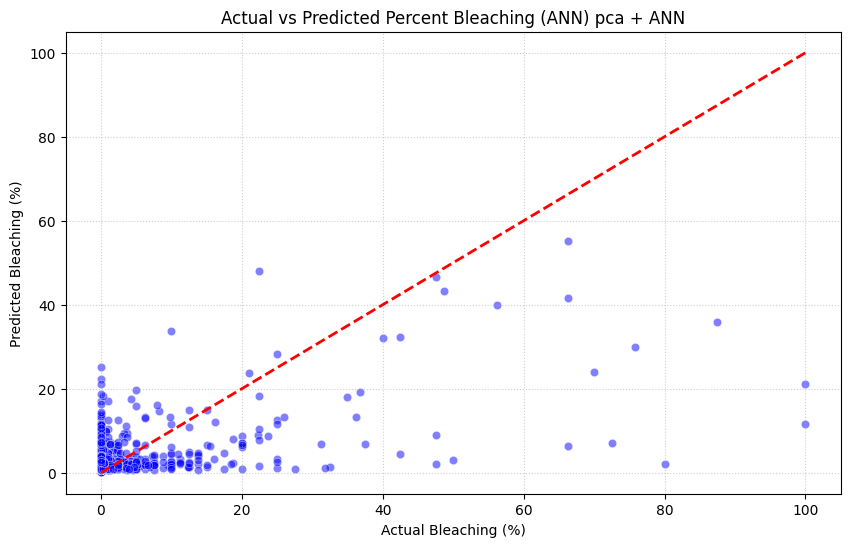

In [38]:
PLOTING_RESULT_ML(rfr_En, X_test_MLEn, y_test_MLEn , 'blue')

In [39]:
rfr_cross_validation_Engineering= cross_validate(rfr_En, X_train_MLEn, y_train_MLEn, cv=5 , scoring= ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']) 

In [40]:
RESULT_K_FOLD(rfr_cross_validation_Engineering,5)

          K-Fold Cross Validation Results (CV = 5)          
Metric     | Mean (Std)      | Scores per Fold
------------------------------------------------------------
R2         | 0.36 (±0.06)   | 0.44, 0.36, 0.34, 0.26, 0.42
RMSE       | 7.72 (±0.37)   | 7.58, 7.84, 8.24, 7.83, 7.11
MAE        | 3.38 (±0.05)   | 3.31, 3.42, 3.45, 3.38, 3.37


In [41]:
Metric_result(rfr_En,X_train_MLEn,X_test_MLEn,y_train_MLEn,y_test_MLEn)

Score on training data: 0.591
------------------------------
Test MSE: 57.747
------------------------------
Test RMSE : 7.599
------------------------------
Test R2 Score : 0.33
------------------------------
Mean Absolute Error : 3.36
------------------------------
Mean Absolute Percentage Error : 5858113486021988.0
------------------------------
(1223,)
(1223,)


In [42]:
feature_importance(rfr_En,feature_En)

Columns have all : 39


,feature,importance
34,Stability,0.10
18,TSA_Frequency_Standard_Deviation,0.09
20,TSA_DHW,0.08
1,Longitude_Degrees,0.08
33,Resistance_Proxy,0.07
0,Latitude_Degrees,0.06
26,DHW_at_risk_medium,0.05
6,Temperature_Maximum,0.04
4,Temperature_Kelvin,0.04
36,Variability,0.04


================================
#### Feature importance > 0.1
================================

In [ ]:
features_to_keep = [
    'Stability', 
    'TSA_Frequency_Standard_Deviation', 
    'Longitude_Degrees', 
    'TSA_DHW', 
    'Resistance_Proxy', 
    'Latitude_Degrees', 
    'DHW_at_risk_medium', 
    'Temperature_Maximum', 
    'Temperature_Kelvin', 
    'Variability', 
    'TSA_DHWMax', 
    'TSA_Frequency', 
    'TSA_Maximum', 
    'ClimSST', 
    'SSTA_Maximum', 
    'SSTA', 
    'Depth_Adjusted_Maximum', 
    'Thermal_shock', 
    'Effective_DHW', 
    'SSTA_Frequency', 
    'SSTA_DHW', 
    'Temperature_Gap', 
    'RSI', 
    'Cumulative_stress', 
    'SSTA_DHWMax', 
    'Frequency_Duration', 
    'SSTA_Minimum', 
    'SSTA_Standard_Deviation', 
    'DHW_at_risk',
    'SSTA_Frequency_Standard_Deviation', 
    'Thermal_Protection', 
    'Windspeed', 
    'Temperature_Mean'
]

# วิธีใช้คัดข้อมูลก่อนนำไปแบ่ง Train/Test
X_filtered = df_clean[features_to_keep]

In [44]:
feature_filter = X_filtered
target_filter = df_clean['Percent_Bleaching']

feature_filter_values = feature_filter.values
target_filer_values = target_filter.values

In [45]:
X_train_filter , X_test_filter , y_train_filter , y_test_filter = train_test_split(feature_filter_values, target_filer_values, test_size=0.2 , random_state=seed)
X_train_filter.shape , X_test_filter.shape , y_train_filter.shape , y_test_filter.shape

((4889, 33), (1223, 33), (4889,), (1223,))

In [46]:
rfr_En.fit(X_train_filter,y_train_filter)

RandomForestRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, n_jobs=-1, random_state=42)

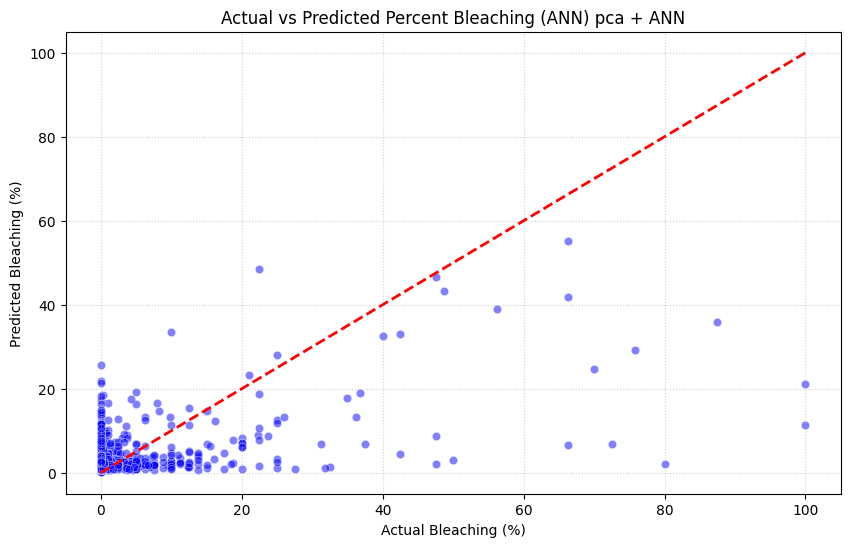

In [47]:
PLOTING_RESULT_ML(rfr_En, X_test_filter, y_test_filter , 'blue')

In [48]:
Metric_result(rfr_En, X_train_filter, X_test_filter, y_train_filter, y_test_filter)

Score on training data: 0.592
------------------------------
Test MSE: 57.86
------------------------------
Test RMSE : 7.607
------------------------------
Test R2 Score : 0.328
------------------------------
Mean Absolute Error : 3.356
------------------------------
Mean Absolute Percentage Error : 5855692275851222.0
------------------------------
(1223,)
(1223,)


In [49]:
feature_importance(rfr_En,feature_filter)

Columns have all : 33


,feature,importance
0,Stability,0.10
1,TSA_Frequency_Standard_Deviation,0.09
3,TSA_DHW,0.09
2,Longitude_Degrees,0.08
4,Resistance_Proxy,0.07
5,Latitude_Degrees,0.06
6,DHW_at_risk_medium,0.04
8,Temperature_Kelvin,0.04
7,Temperature_Maximum,0.04
9,Variability,0.04


##

==================
### XGBRegessor
==================

In [79]:
# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
xgb_modelEn = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
    learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
    subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
    colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
    random_state=seed,
    n_jobs=-1
)

# 2. เทรนโมเดล
xgb_modelEn.fit(X_train_filter, y_train_filter)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

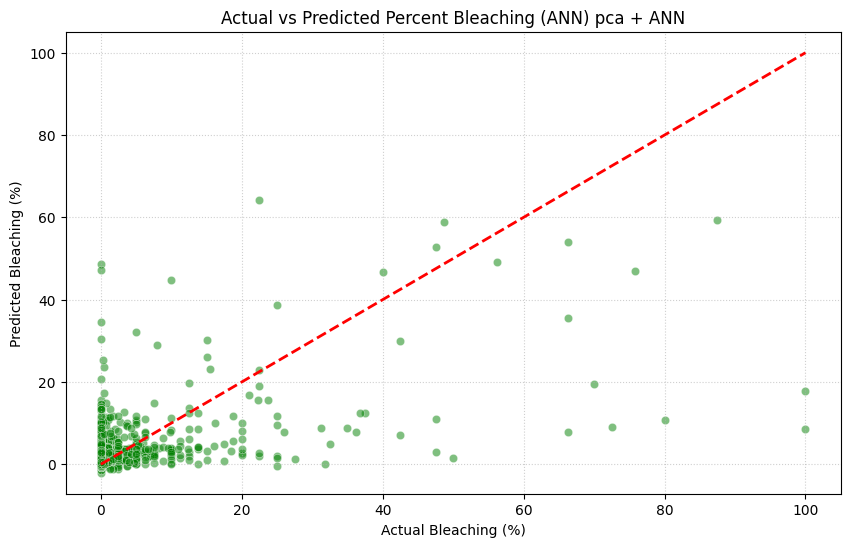

In [81]:
PLOTING_RESULT_ML(xgb_modelEn, X_test_filter, y_test_filter , 'green')

In [82]:
Metric_result(xgb_modelEn,X_train_filter,X_test_filter,y_train_filter,y_test_filter)

Score on training data: 0.915
------------------------------
Test MSE: 62.202
------------------------------
Test RMSE : 7.887
------------------------------
Test R2 Score : 0.278
------------------------------
Mean Absolute Error : 3.223
------------------------------
Mean Absolute Percentage Error : 4994385311556811.0
------------------------------
(1223,)
(1223,)


##

In [53]:
#------------------------------------------------------------------------#
# โมเดล Average bleaching
#------------------------------------------------------------------------#


y_pred_Averagemodel = df_Clean_already[['Percent_Bleaching']].mean()

def RMSE(df):
    y_true = df['Percent_Bleaching'].values
    total = 0
    
    for i in range(len(y_true)):
        error = y_true[i] - y_pred_Averagemodel
        total += error**2
    
    rmse = np.sqrt(total / len(y_true))
    return rmse

print(f"RMSE : {RMSE(df_Clean_already).round(2)}")

def R2_score(df):
    y_true = df['Percent_Bleaching'].values
    
    y_mean = np.mean(y_true)
    
    ss_res = 0  # sum of squared residuals
    ss_tot = 0  # total sum of squares
    
    for i in range(len(y_true)):
        ss_res += (y_true[i] - y_pred_Averagemodel)**2
        ss_tot += (y_true[i] - y_mean)**2
    
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"SS_res : {ss_res.round(1)}")
    print(f"SS_tot : {ss_tot.round(1)}")
    
    return r2

print(f"Percent_bleaching : {y_pred_Averagemodel}")
print("-"*50)
print(f"R2_score (rounded): {R2_score(df_Clean_already)}") # predicted less than mean so R2 is negative

RMSE : Percent_Bleaching    9.63
dtype: float64
Percent_bleaching : Percent_Bleaching    2.79522
dtype: float64
--------------------------------------------------
SS_res : Percent_Bleaching    567199.4
dtype: float64
SS_tot : 567199.4
R2_score (rounded): Percent_Bleaching    0.0
dtype: float64


##

=======================================
### Artificial Neural Network
=======================================

In [54]:
# tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense , Dropout, Input
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanSquaredError
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler , RobustScaler
from sklearn.model_selection import KFold


In [55]:
def Divide_data(df_feature, df_target, n_train):
    
    n = len(df_feature)
    n_train = n * n_train
    n_train = int(n_train)
    
    return df_feature[:n_train], df_feature[n_train:], df_target[:n_train], df_target[n_train:]

X_trainANN_En, X_testANN_En, y_trainANN_En, y_testANN_En = Divide_data(feature_En_values, target_En_values, 0.8)
X_trainANN_En.shape, X_testANN_En.shape , y_trainANN_En.shape, y_testANN_En.shape
    

((4889, 39), (1223, 39), (4889,), (1223,))

In [56]:
from keras.layers import BatchNormalization

def model_ANN(X_train):
        model = Sequential( 
        [
            Dense(8, activation= 'relu', input_shape=(X_train.shape[1],)),
            Dropout(0.1),
            Dense(2, activation= 'relu'),
            Dense(1)
        ]
    )
        return model
    
def model_ANN_Enhanced(X_train):
    model = Sequential([
        # Layer 1: ต้องเริ่มด้วยการบอกขนาด Input
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        
        # Layer 2: ชั้นที่คุณเพิ่มเข้ามา
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.1),
        
        # Layer 3: ชั้นเดิม
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.1),
        
        # Output: ต้องเป็น 1 และห้ามมี activation (หรือเป็น linear)
        Dense(1, activation='linear')
    ])
    
    return model


model_gimini = model_ANN_Enhanced(X_testANN_En)
model_En = model_ANN(X_trainANN_En)
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
#------------------------------------------------------------------#

In [57]:
model_gimini.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2560      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 3

In [58]:
def K_Fold_cross_validation(model, X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    Epoch = [8, 16, 32, 64, 128]
    Batch_size = [8, 16, 32, 64]
    fold = 1
    Error = []

    for train_idx, val_idx in kf.split(X_train):
        
        print(f"\n==================== Fold {fold} ====================")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # ✅ 1. Reshape y ให้เป็น 2 มิติเพื่อเข้า Scaler
        y_tr_reshaped = y_tr.reshape(-1, 1)
        y_val_reshaped = y_val.reshape(-1, 1)

        # ✅ 2. ใช้ RobustScaler (แนะนำให้ใช้ตัวนี้คู่กับ Log Transform จะดีกับ ANN ที่สุดครับ)
        scaler_X = RobustScaler()
        scaler_y = RobustScaler()
        
        # ✅ 3. Fit และ Transform **เฉพาะข้อมูล Train (X_tr, y_tr)** ของ Fold นี้
        X_tr_scaled = scaler_X.fit_transform(X_tr)
        y_tr_scaled = scaler_y.fit_transform(y_tr_reshaped)
        
        # ✅ 4. Transform ข้อมูล Validation โดยใช้ความรู้จาก Train
        X_val_scaled = scaler_X.transform(X_val)
        y_val_scaled = scaler_y.transform(y_val_reshaped)

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
        )

        # ✅ 5. โยนข้อมูลที่ **Scale แล้ว** เข้าไปเทรนโมเดล
        history = model.fit(
            X_tr_scaled, y_tr_scaled,
            validation_data=(X_val_scaled, y_val_scaled),
            epochs=Epoch[3],
            batch_size=Batch_size[1],
            callbacks=[early_stopping], # ตรวจสอบให้แน่ใจว่าประกาศตัวแปรนี้ไว้ข้างนอกแล้ว
            verbose=1
        )

        # ✅ 6. คืนร่าง Target (Inverse Transform) ก่อนหาค่า Error จริง
        # ให้โมเดลทำนายจาก X_val_scaled
        y_pred_scaled = model.predict(X_val_scaled)
        
        # แปลงกลับเป็นสเกล 0-100% 
        y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
        y_val_real = y_val.flatten() # ใช้ค่า y_val ดั้งเดิมที่ยังไม่ถูก Scale มาเทียบได้เลย
        
        # คำนวณ Metrics จากสเกลจริง (ทำให้ MAE และ RMSE อ่านค่าได้เข้าใจง่าย)
        rmse_real = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
        mae_real = mean_absolute_error(y_val_real, y_pred_real)
        r2_real = r2_score(y_val_real, y_pred_real)

        # ดึงค่า Loss (MSE) จากสเกลเลอร์ของ Keras เพื่อเก็บ History
        loss = model.evaluate(X_val_scaled, y_val_scaled, verbose=0)[0] 

        Error.append({
            "Storage RMSE Fold": fold,
            "loss": loss,
            "MAE": mae_real,          # ✅ เก็บค่าจริง
            "RMSE Values": rmse_real, # ✅ เก็บค่าจริง
            'R2' : r2_real,           # ✅ เก็บค่าจริง
            "history_of_loss": history.history['loss'],
            "history_of_val_loss": history.history['val_loss']
        })

        fold += 1

    return Error , scaler_X, scaler_y

#------------------------------------------------------------------------------------------#
Error_En , scaler_X , scaler_y = K_Fold_cross_validation(model_En, X_trainANN_En, y_trainANN_En)
#------------------------------------------------------------------------------------------#


==================== Fold 1 ====================
Epoch 1/64

245/245 [==============================] - 1s 2ms/step - loss: 96.7227 - root_mean_squared_error: 9.8348 - mean_absolute_error: 2.7796 - val_loss: 77.7216 - val_root_mean_squared_error: 8.8160 - val_mean_absolute_error: 2.6740
Epoch 2/64
245/245 [==============================] - 0s 988us/step - loss: 95.3941 - root_mean_squared_error: 9.7670 - mean_absolute_error: 2.7947 - val_loss: 76.8362 - val_root_mean_squared_error: 8.7656 - val_mean_absolute_error: 2.7100
Epoch 3/64
245/245 [==============================] - 0s 1ms/step - loss: 94.4994 - root_mean_squared_error: 9.7211 - mean_absolute_error: 2.8540 - val_loss: 76.1162 - val_root_mean_squared_error: 8.7245 - val_mean_absolute_error: 2.7608
Epoch 4/64
245/245 [==============================] - 0s 1ms/step - loss: 93.7919 - root_mean_squared_error: 9.6846 - mean_absolute_error: 2.9184 - val_loss: 75.4751 - val_root_mean_squared_error: 8.6876 - val_mean_absolute_error: 2.

         K-Fold Cross Validation Results
 Fold      Loss     RMSE      MAE       R2
    1 67.339821 8.206085 3.409109 0.059151
    2 79.893974 8.938343 3.549460 0.134116
    3 99.980606 9.999031 3.718621 0.123038
    4 51.379784 7.167969 3.144435 0.142750
    5 75.136040 8.668104 3.598534 0.165069
  Mean  Loss : 74.7460
  Std   Loss : 17.7783
------------------------------
  Mean  RMSE : 8.5959
  Std   RMSE : 1.0347
------------------------------
  Mean  MAE  : 3.4840
  Std   MAE  : 0.2199
------------------------------
  Mean  R2   : 0.1248
  Std   R2   : 0.0398


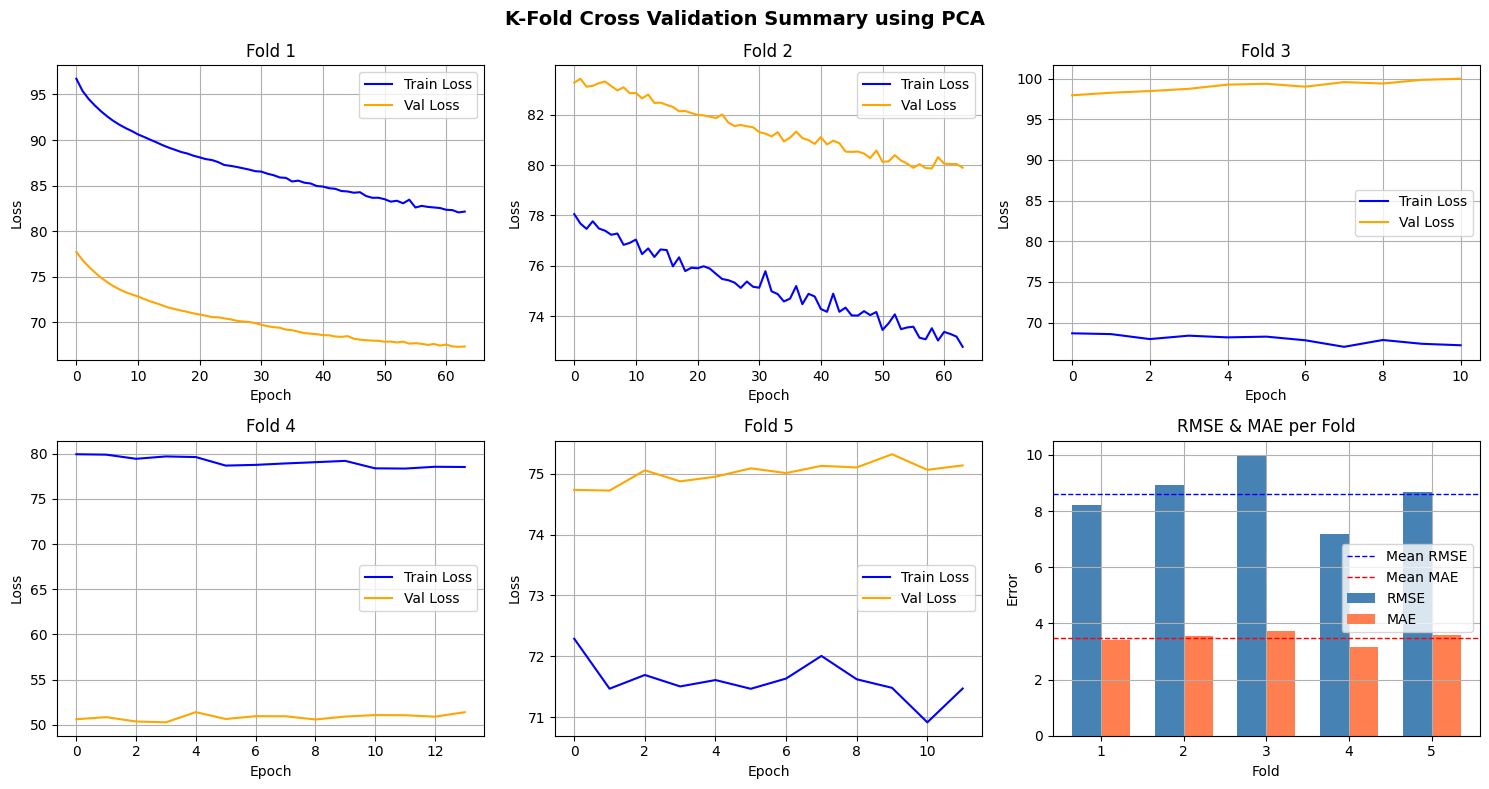

In [59]:
def show_kfold_results(Error):
    
    # ── 1. สรุปตาราง ──────────────────────────────────────────
    df_results = pd.DataFrame([{
        "Fold"  : e["Storage RMSE Fold"],
        "Loss"  : e["loss"],
        "RMSE"  : e["RMSE Values"],
        "MAE"   : e["MAE"],
        "R2"    : e["R2"]
    } for e in Error])
    
    print("=" * 50)
    print("         K-Fold Cross Validation Results")
    print("=" * 50)
    print(df_results.to_string(index=False))
    print("=" * 50)
    print(f"  Mean  Loss : {df_results['Loss'].mean():.4f}")
    print(f"  Std   Loss : {df_results['Loss'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  RMSE : {df_results['RMSE'].mean():.4f}")
    print(f"  Std   RMSE : {df_results['RMSE'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  MAE  : {df_results['MAE'].mean():.4f}")
    print(f"  Std   MAE  : {df_results['MAE'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  R2   : {df_results['R2'].mean():.4f}")
    print(f"  Std   R2   : {df_results['R2'].std():.4f}")
    print("=" * 50)
    
    # ── 2. Plot Loss curve แต่ละ Fold ─────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, e in enumerate(Error):
        ax = axes[i]
        ax.plot(e["history_of_loss"],     label="Train Loss", color="blue")
        ax.plot(e["history_of_val_loss"], label="Val Loss",   color="orange")
        ax.set_title(f"Fold {e['Storage RMSE Fold']}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)
    
    # ── slot สุดท้าย → สรุป RMSE/MAE ทุก fold ────────────────
    ax = axes[len(Error)]
    x = df_results["Fold"]
    width = 0.35
    ax.bar(x - width/2, df_results["RMSE"], width, label="RMSE", color="steelblue")
    ax.bar(x + width/2, df_results["MAE"],  width, label="MAE",  color="coral")
    ax.axhline(df_results["RMSE"].mean(), color="blue",   linestyle="--", linewidth=1, label="Mean RMSE")
    ax.axhline(df_results["MAE"].mean(),  color="red",    linestyle="--", linewidth=1, label="Mean MAE")
    ax.set_title("RMSE & MAE per Fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Error")
    ax.set_xticks(x)
    ax.legend()
    ax.grid(True)
    
    plt.suptitle("K-Fold Cross Validation Summary using PCA", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_results

def evaluate_model(model, X_test, y_test, scaler_y=None): # เรียกใช้เมื่อ train โมเดลด้วยข้อมูลทั้งหมดเพราะเป็นการ evaluate กับ ข้อมูลทั้งหมด
    
    y_pred = model.predict(X_test).flatten()

    # ── Inverse transform กลับเป็นค่าจริง ──────────────
    if scaler_y is not None:
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print("=" * 40)
    print("        Model Performance (Real Scale)")
    print("=" * 40)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print("=" * 40)


def PLOTING_DEEP_LEARNING(model, X_test, y_test, scale, CL):
    # 1. Predict ค่าออกมา (ค่าที่ได้จะยังเป็นสเกลที่ถูกแปลงอยู่)
    y_pred_scaled = model.predict(X_test)

    # 2. แปลงค่ากลับเป็นสเกลปกติ (เปอร์เซ็นต์) ด้วย inverse_transform
    # หมายเหตุ: .reshape(-1, 1) เผื่อไว้ในกรณีที่ y_pred ออกมาเป็น 1D
    y_pred_original = scale.inverse_transform(y_pred_scaled.reshape(-1, 1))

    # 3. แปลงกลับเป็น 1D สำหรับการพล็อตกราฟ
    y_pred_plot = y_pred_original.ravel()
    
    # *ข้อควรระวัง*: y_test ที่รับเข้ามา ต้องเป็นสเกลปกติ (%) ด้วยนะครับ 
    # (ถ้า y_test เป็นค่าที่โดนสเกลมา ต้อง inverse_transform y_test ด้วยเช่นกัน)

    plt.figure(figsize=(10, 6))

    # พล็อต Scatter
    sns.scatterplot(
        x=y_test, 
        y=y_pred_plot,
        alpha=0.5,
        color=CL
    )

    # 4. หาขอบเขตที่กว้างที่สุดสำหรับวาดเส้น Ideal Line (ใช้ค่าจากพารามิเตอร์ ไม่ใช่ตัวแปร Global)
    min_val = min(np.min(y_test), np.min(y_pred_plot))
    max_val = max(np.max(y_test), np.max(y_pred_plot))

    # เส้น ideal line (Perfect prediction)
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title('Actual vs Predicted Percent Bleaching (ANN) pca + ANN')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# เรียกใช้
df_results = show_kfold_results(Error_En)

In [60]:
X_testANNEn_scaled = scaler_X.transform(X_testANN_En)
y_testANNEn_scaled = scaler_y.transform(y_testANN_En.reshape(-1,1)).flatten()


39/39 [==============================] - 0s 767us/step


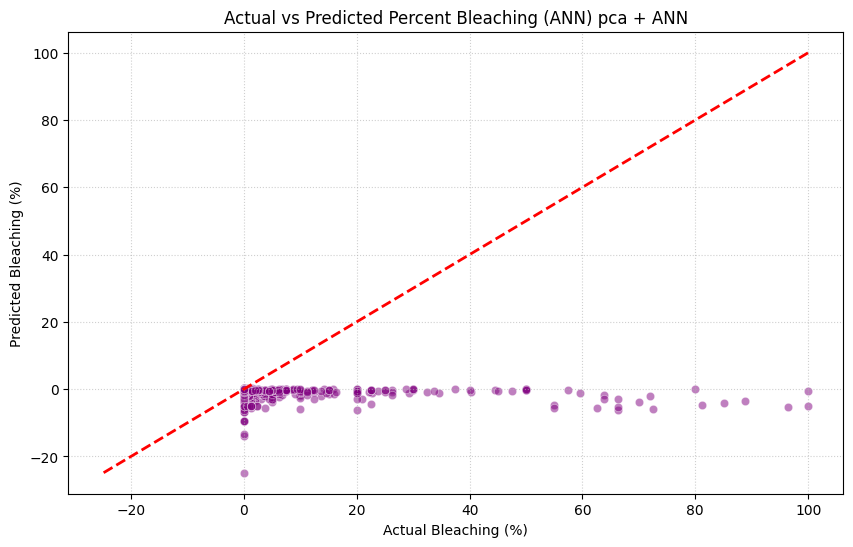

In [61]:
PLOTING_DEEP_LEARNING(model_gimini, X_testANNEn_scaled, y_testANN_En , scaler_y , 'purple')

In [62]:
evaluate_model(model_En, X_testANNEn_scaled, y_testANNEn_scaled, scaler_y)

39/39 [==============================] - 0s 536us/step
        Model Performance (Real Scale)
  MSE  : 115.7159
  RMSE : 10.7571
  MAE  : 4.3331
  R²   : 0.0449


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
import numpy as np

# ==========================================
# 1. ฟังก์ชันสร้างโมเดล (ต้องเรียกใหม่ทุก Fold)
# ==========================================
def build_model(input_dim, nodes=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    # Layer 1
    model.add(Dense(nodes, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))
    # Layer 2 (ลดโหนดลงครึ่งนึง คล้ายทรงกรวย)
    model.add(Dense(nodes // 2, activation='relu'))
    model.add(Dropout(dropout_rate))
    # Output Layer
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# ==========================================
# 2. ฟังก์ชัน Grid Search + K-Fold
# ==========================================
def tune_hyperparameters(X_train, y_train):
    # กำหนดสูตรผสมที่อยากทดสอบ
    param_grid = {
        'nodes': [16, 32],
        'dropout_rate': [0.1, 0.2],
        'learning_rate': [0.01, 0.001],
        'batch_size': [16, 32]
    }
    
    best_r2 = -float('inf')
    best_params = {}
    
    # ดึงค่า input_dim (จำนวน Features) จาก X_train
    input_dim = X_train.shape[1]
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # วนลูปทดสอบทุกสูตรผสม
    for n in param_grid['nodes']:
        for d in param_grid['dropout_rate']:
            for lr in param_grid['learning_rate']:
                for b in param_grid['batch_size']:
                    
                    print(f"\n[Testing] Nodes:{n} | Dropout:{d} | LR:{lr} | Batch:{b}")
                    
                    kf = KFold(n_splits=5, shuffle=True, random_state=42)
                    fold_r2 = []
                    
                    for train_idx, val_idx in kf.split(X_train):
                        X_tr, X_val = X_train[train_idx], X_train[val_idx]
                        y_tr, y_val = y_train[train_idx], y_train[val_idx]
                        
                        y_tr_reshaped = y_tr.reshape(-1, 1)
                        y_val_reshaped = y_val.reshape(-1, 1)
                        
                        scaler_X = RobustScaler()
                        scaler_y = RobustScaler()
                        
                        X_tr_scaled = scaler_X.fit_transform(X_tr)
                        y_tr_scaled = scaler_y.fit_transform(y_tr_reshaped)
                        
                        X_val_scaled = scaler_X.transform(X_val)
                        y_val_scaled = scaler_y.transform(y_val_reshaped)
                        
                        # *** จุดสำคัญ: สร้างโมเดลใหม่เอี่ยมทุกๆ Fold ***
                        model = build_model(input_dim=input_dim, nodes=n, dropout_rate=d, learning_rate=lr)
                        
                        model.fit(
                            X_tr_scaled, y_tr_scaled,
                            validation_data=(X_val_scaled, y_val_scaled),
                            epochs=64, # ล็อกไว้ที่ 64 เพราะมี Early Stopping ช่วยเบรกอยู่แล้ว
                            batch_size=b,
                            callbacks=[early_stopping],
                            verbose=0 # ซ่อน log เพื่อไม่ให้รกหน้าจอ
                        )
                        
                        y_pred_scaled = model.predict(X_val_scaled, verbose=0)
                        y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
                        y_val_real = y_val.flatten()
                        
                        r2_real = r2_score(y_val_real, y_pred_real)
                        fold_r2.append(r2_real)
                    
                    mean_r2 = np.mean(fold_r2)
                    print(f"--> Mean R2: {mean_r2:.4f}")
                    
                    # เก็บสูตรที่ดีที่สุดไว้
                    if mean_r2 > best_r2:
                        best_r2 = mean_r2
                        best_params = {'nodes': n, 'dropout_rate': d, 'learning_rate': lr, 'batch_size': b}

    print("\n" + "="*50)
    print(f"🏆 BEST R2 SCORE: {best_r2:.4f}")
    print(f"⭐ BEST PARAMS: {best_params}")
    print("="*50)
    
    return best_params

# วิธีใช้งาน:
best_hyperparameters = tune_hyperparameters(X_trainANN_En, y_trainANN_En)

##

### การทดลองนี้ใช้เพื่อเปรัยบเทียบว่าการทำ Feature Engineering ของผมสามารถเพิ่มประสิทธิภาพของโมเดลได้ดีกว่าการนำตัวแปรเปล่าๆของ dataset เข้าโมเดลเดียวกัน

In [63]:
feature_ALL = df_Clean_already.drop(columns=['Percent_Bleaching'])
target_ALL = df_Clean_already[['Percent_Bleaching']]

feature_ALL_values = feature_ALL.values
target_ALL_values = target_ALL.values

X_trainANNALL , X_testANNALL , y_trainANNALL , y_testANNALL = Divide_data(feature_ALL_values, target_ALL_values, 0.8)
X_trainANNALL.shape , X_testANNALL.shape , y_testANNALL.shape , y_testANNALL.shape

((4889, 35), (1223, 35), (1223, 1), (1223, 1))

In [64]:
model_gimini_ALLfeature = model_ANN_Enhanced(X_trainANNALL)

In [65]:
#----------------------------------------------------------------------------------------------------------------------#
Error_featureALL , scaler_X , scaler_y = K_Fold_cross_validation(model_gimini_ALLfeature, X_trainANNALL, y_trainANNALL)
#----------------------------------------------------------------------------------------------------------------------#


==================== Fold 1 ====================
Epoch 1/64
245/245 [==============================] - 1s 2ms/step - loss: 85.8545 - root_mean_squared_error: 9.2658 - mean_absolute_error: 3.7234 - val_loss: 66.6484 - val_root_mean_squared_error: 8.1638 - val_mean_absolute_error: 3.5689
Epoch 2/64
245/245 [==============================] - 0s 1ms/step - loss: 79.9069 - root_mean_squared_error: 8.9391 - mean_absolute_error: 3.8360 - val_loss: 66.6394 - val_root_mean_squared_error: 8.1633 - val_mean_absolute_error: 3.9245
Epoch 3/64
245/245 [==============================] - 0s 1ms/step - loss: 76.4391 - root_mean_squared_error: 8.7429 - mean_absolute_error: 3.7300 - val_loss: 62.9835 - val_root_mean_squared_error: 7.9362 - val_mean_absolute_error: 3.4290
Epoch 4/64
245/245 [==============================] - 0s 1ms/step - loss: 75.3272 - root_mean_squared_error: 8.6791 - mean_absolute_error: 3.6259 - val_loss: 61.1512 - val_root_mean_squared_error: 7.8199 - val_mean_absolute_error: 3.497

In [66]:
X_testANNALL_scaled = scaler_X.transform(X_testANNALL)
y_testANNALL_scaled = scaler_y.transform(y_testANNALL.reshape(-1,1)).flatten()

         K-Fold Cross Validation Results
 Fold      Loss     RMSE      MAE       R2
    1 53.298126 7.300556 2.927583 0.255337
    2 39.839058 6.311819 2.676822 0.568228
    3 68.021286 8.247502 2.925233 0.403363
    4 31.874458 5.645747 2.272588 0.468188
    5 31.896729 5.647719 2.525063 0.645555
  Mean  Loss : 44.9859
  Std   Loss : 15.5680
------------------------------
  Mean  RMSE : 6.6307
  Std   RMSE : 1.1293
------------------------------
  Mean  MAE  : 2.6655
  Std   MAE  : 0.2786
------------------------------
  Mean  R2   : 0.4681
  Std   R2   : 0.1508


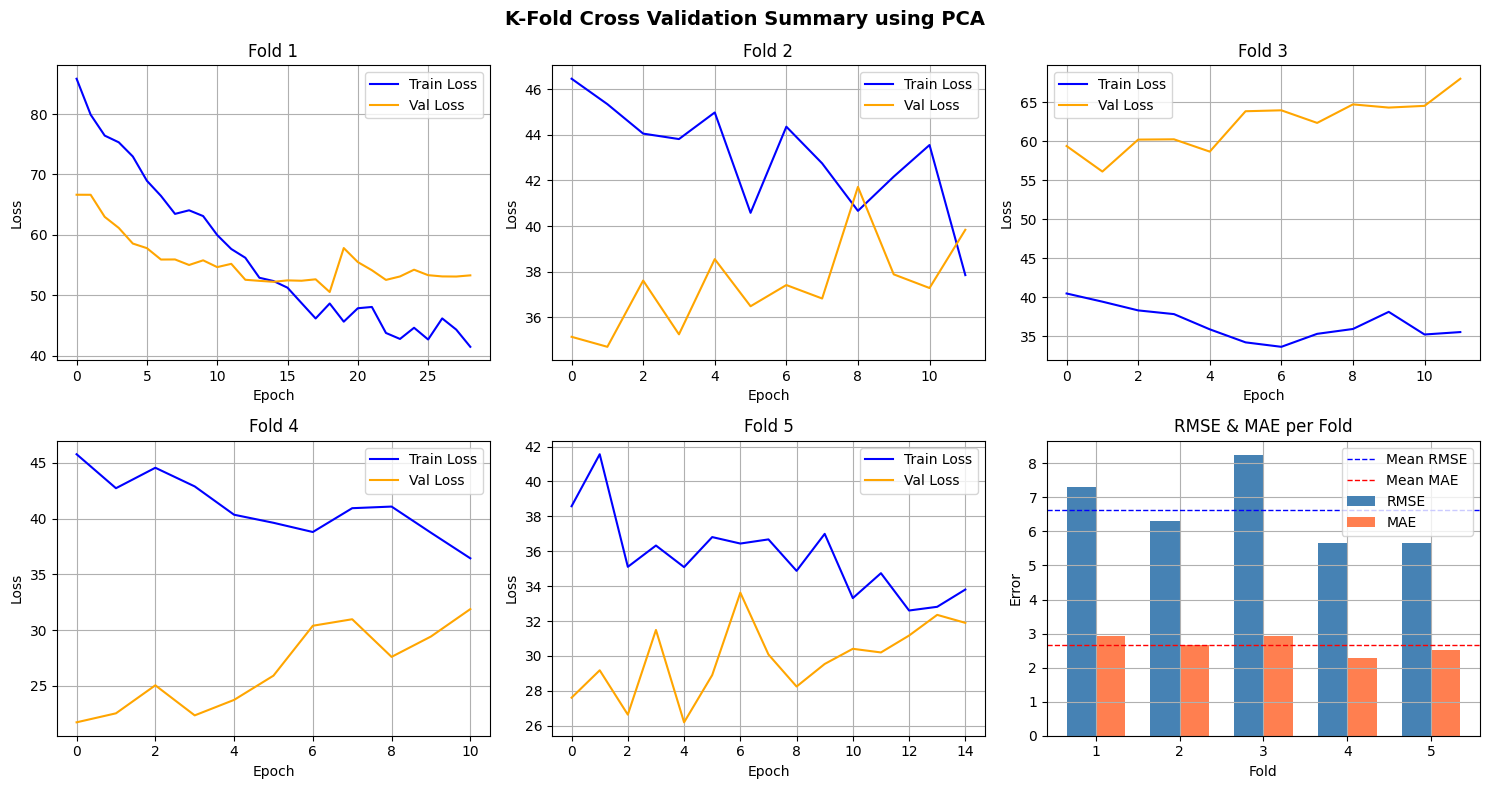

In [67]:
df_results = show_kfold_results(Error_featureALL)

39/39 [==============================] - 0s 543us/step


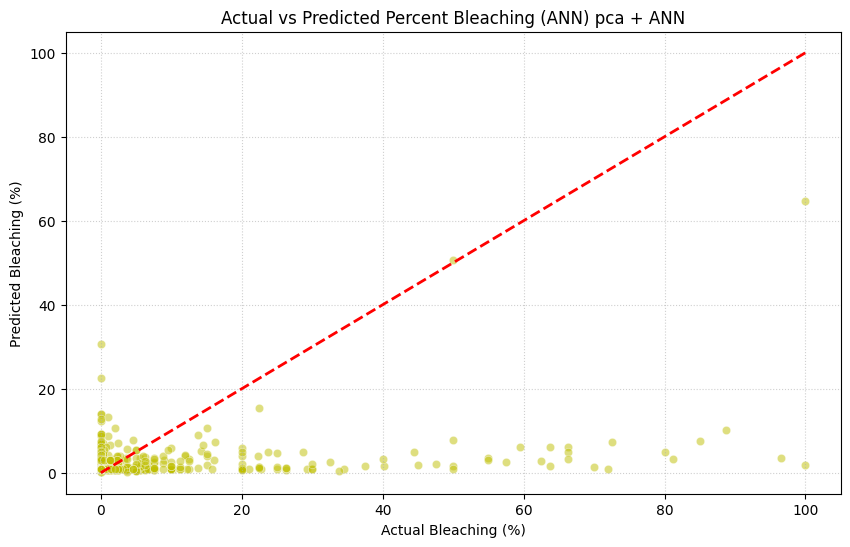

In [68]:
y_testANNALL = y_testANNALL.flatten()
PLOTING_DEEP_LEARNING(model_gimini_ALLfeature, X_testANNALL_scaled, y_testANNALL , scaler_y , 'y')

In [69]:
evaluate_model(model_gimini_ALLfeature, X_testANNALL_scaled, y_testANNALL_scaled, scaler_y)

39/39 [==============================] - 0s 542us/step
        Model Performance (Real Scale)
  MSE  : 110.0166
  RMSE : 10.4889
  MAE  : 3.7156
  R²   : 0.0919


##

##

### Correlation เราต้องบอกว่า % กับ Depth_m ธรรมดา / % กับ SSTA ธรรมดา  เเล้วทำมาเทียบกับ feature engineering ผลลัพธ์ของ feature engineer ดีกว่าหรือเเย่กว่าอย่างไร พร้อมอธิบายเหตุผลของ feature engineer ที่ทำขึ้นมาด้วย

In [70]:
custom_features = [
    'Thermal_Protection', 'Cumulative_stress', 'Depth_Adjusted_Maximum',
    'Frequency_Duration', 'RSI', 'Resistance_Proxy', 'Stability',
    'Effective_DHW', 'Variability', 'Temperature_Gap', 'Thermal_shock'
]

correlations = df_final[custom_features + ['Percent_Bleaching']].corr()['Percent_Bleaching']
print("Correlation of Engineered Features with Target:")
print(correlations)

Correlation of Engineered Features with Target:
Thermal_Protection        0.167699
Cumulative_stress         0.155720
Depth_Adjusted_Maximum   -0.017741
Frequency_Duration        0.109501
RSI                       0.176176
Resistance_Proxy         -0.131070
Stability                -0.103106
Effective_DHW             0.160276
Variability               0.037741
Temperature_Gap          -0.009950
Thermal_shock             0.060969
Percent_Bleaching         1.000000
Name: Percent_Bleaching, dtype: float64


In [71]:
baseline_feature = [
    'Depth_m' , 'SSTA_DHW' , 'SSTA' , 'Temperature_Maximum'
]

baseline_correlation = df_final[baseline_feature + ['Percent_Bleaching']].corr()['Percent_Bleaching']
print("Correlation of baseline :")
print(baseline_correlation)

Correlation of baseline :
Depth_m                0.027032
SSTA_DHW               0.176013
SSTA                   0.061674
Temperature_Maximum    0.014305
Percent_Bleaching      1.000000
Name: Percent_Bleaching, dtype: float64


##

## Two-stage model

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [123]:
# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_clean['stratify_col'] = (df_clean['Percent_Bleaching'] > 0).astype(int)
df_clean[['stratify_col']].value_counts()

stratify_col
0               3914
1               2198
Name: count, dtype: int64

In [124]:
df_Twostage_model = df_clean.copy()

In [125]:
df_Twostage_model[['stratify_col']].value_counts()

stratify_col
0               3914
1               2198
Name: count, dtype: int64

In [126]:
X = df_Twostage_model.drop(columns=['Percent_Bleaching', 'stratify_col'])
y = df_Twostage_model[['stratify_col']]

X_values = X.values
y_values = y.values



In [129]:
def set_datapretrain(X,y):
    X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
    
    return X_train_class, X_test_class, y_train_class , y_test_class

X_train_class , X_test_class , y_train_class , y_test_class = set_datapretrain(X,y)


def training_model():
    rf_class = RandomForestClassifier(
    n_estimators=200, max_features="sqrt",
    class_weight="balanced", random_state=42)

    rf_class.fit(X_train_class, y_train_class)

    y_pred = rf_class.predict(X_test_class)
    print(classification_report(y_test_class, y_pred))
    print("AUC:", roc_auc_score(y_test_class, rf_class.predict_proba(X_test_class)[:,1]))
    
    return rf_class, y_pred
    
rf_class, y_pred_class = training_model()

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.80      0.86      0.83       783
           1       0.72      0.62      0.66       440

    accuracy                           0.78      1223
   macro avg       0.76      0.74      0.75      1223
weighted avg       0.77      0.78      0.77      1223

AUC: 0.8299793916173227


ALL train data : 1223


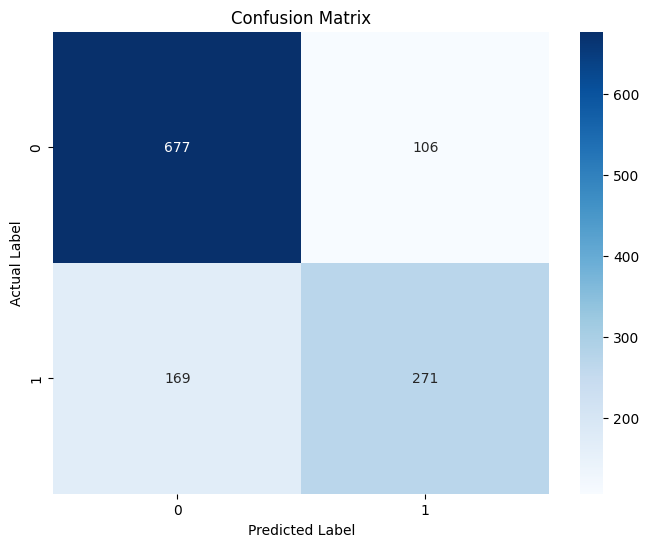

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
print(f"ALL train data : {len(y_test_class)}")
plot_confusion_matrix(y_test_class, y_pred_class, ['0','1'])

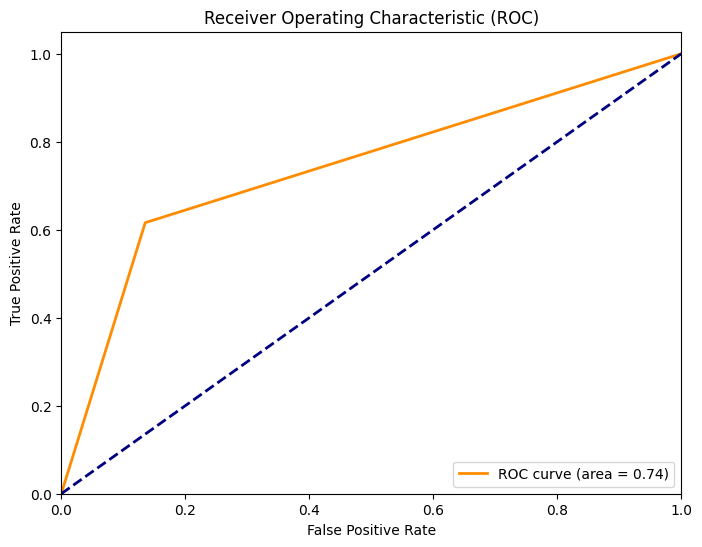

In [131]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_probs):
    # y_probs คือค่าความน่าจะเป็น (probability) ของคลาส 1
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()
    
plot_roc_curve(y_test_class,y_pred_class)

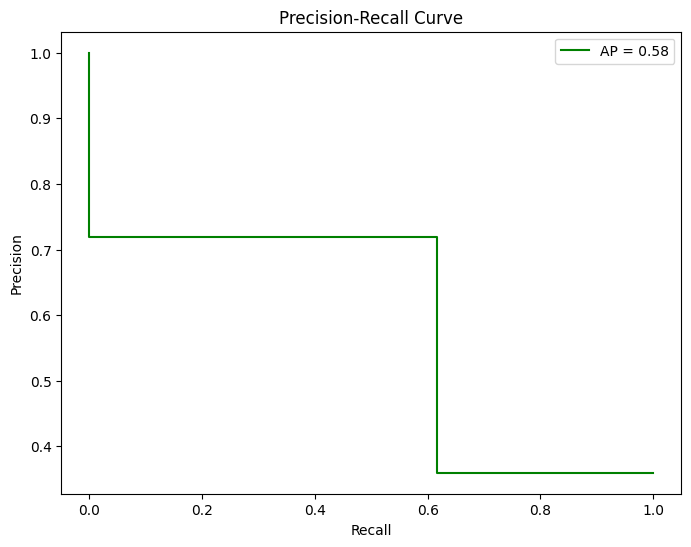

In [132]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(y_true, y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    avg_precision = average_precision_score(y_true, y_probs)

    plt.figure(figsize=(8, 6))
    plt.step(recall, precision, where='post', color='green', label=f'AP = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="upper right")
    plt.show()
    
plot_precision_recall(y_test_class,y_pred_class)

In [133]:
feature_importance(rf_class,X)

Columns have all : 39


,feature,importance
0,Latitude_Degrees,0.07
1,Longitude_Degrees,0.07
4,Temperature_Kelvin,0.04
30,Depth_Adjusted_Maximum,0.04
5,Temperature_Mean,0.04
31,Frequency_Duration,0.03
3,ClimSST,0.03
13,SSTA_Frequency_Standard_Deviation,0.03
33,Resistance_Proxy,0.03
34,Stability,0.03
